In [1]:
 !pip install -q ydata_profiling # data report
!pip install -q scikit_learn  # ML models

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 2.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport
import warnings
warnings.filterwarnings('ignore')

from google.colab import files
uploaded = files.upload()

#scikit_learn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder,OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import(accuracy_score,precision_score,recall_score,f1_score,
                            confusion_matrix,classification_report,roc_auc_score)
from scipy.stats import zscore


sns.set_style('whitegrid')
plt.rcParams['figure.figsize']=(12,6)




/tmp/ipykernel_1815/1937315525.py:5: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [3]:
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")


In [4]:
df.drop(columns=["customerID"],axis=1,inplace=True)

In [5]:
df.drop(columns=["gender"],axis=1,inplace=True)

In [6]:
# family features
def family_status(row):
      if row['Partner'] == 'Yes' and row['Dependents'] == 'Yes':
        return 2
      elif row['Partner'] == 'Yes' and row['Dependents'] == 'No':
        return 1
      else:
        return 0
df['family_status'] = df.apply(family_status, axis=1)

In [7]:
df.drop(columns=["Partner","Dependents"],axis=1,inplace=True)

In [8]:
#phone line
def phone_line(row):
      if row["PhoneService"] == "No":
        return 0  #مفيش خط ابدا
      elif row["PhoneService"] == "Yes" and row["MultipleLines"] == "No" :
        return 1 # مفيش غير خط واحد
      else:
        return 2

df['phone_line'] = df.apply(phone_line, axis=1)

In [9]:
df["phone_line"].unique()

array([0, 1, 2])

In [10]:
df.drop(columns=["MultipleLines","PhoneService"],axis=1,inplace=True)

In [11]:
order={'No':0,'DSL':1,'Fiber optic':2}
df['InternetService']=df['InternetService'].map(order)

In [12]:
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies','PaperlessBilling']

df['TotalServices'] = (df[service_cols] == 'Yes').sum(axis=1)

In [13]:
df.drop(columns= ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies','PaperlessBilling'],axis=1,inplace=True)

In [14]:
df = pd.get_dummies(df, columns=['PaymentMethod'])


In [15]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})



In [16]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].isnull().sum()
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [17]:
contract_map = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}

df['Contract'] = df['Contract'].map(contract_map)

In [18]:
df['PaymentMethod_Bank transfer (automatic)']=df['PaymentMethod_Bank transfer (automatic)'].astype(int)
df['PaymentMethod_Credit card (automatic)']=df['PaymentMethod_Credit card (automatic)'].astype(int)
df['PaymentMethod_Electronic check']=df['PaymentMethod_Electronic check'].astype(int)
df['PaymentMethod_Mailed check']=df['PaymentMethod_Mailed check'].astype(int)

In [19]:
df.drop_duplicates(inplace=True)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6993 entries, 0 to 7042
Data columns (total 14 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   SeniorCitizen                            6993 non-null   int64  
 1   tenure                                   6993 non-null   int64  
 2   InternetService                          6993 non-null   int64  
 3   Contract                                 6993 non-null   int64  
 4   MonthlyCharges                           6993 non-null   float64
 5   TotalCharges                             6993 non-null   float64
 6   Churn                                    6993 non-null   int64  
 7   family_status                            6993 non-null   int64  
 8   phone_line                               6993 non-null   int64  
 9   TotalServices                            6993 non-null   int64  
 10  PaymentMethod_Bank transfer (automatic)  6993 non-nul

In [21]:
#view report about sataset
profile = ProfileReport(df, title= "Report")


#calling profile
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 14/14 [00:00<00:00, 40.09it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [22]:
df

,SeniorCitizen,tenure,InternetService,Contract,MonthlyCharges,TotalCharges,Churn,family_status,phone_line,TotalServices,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,1,0,29.85,29.85,0,1,0,2,0,0,1,0
1,0,34,1,1,56.95,1889.50,0,0,1,2,0,0,0,1
2,0,2,1,0,53.85,108.15,1,0,1,3,0,0,0,1
3,0,45,1,1,42.30,1840.75,0,0,0,3,1,0,0,0
4,0,2,2,0,70.70,151.65,1,0,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,1,1,84.80,1990.50,0,2,2,6,0,0,0,1
7039,0,72,2,1,103.20,7362.90,0,2,2,5,0,1,0,0
7040,0,11,1,0,29.60,346.45,0,2,0,2,0,0,1,0
7041,1,4,2,0,74.40,306.60,1,1,2,1,0,0,0,1


In [23]:
df['TotalCharges'] = np.log1p(df['TotalCharges'])

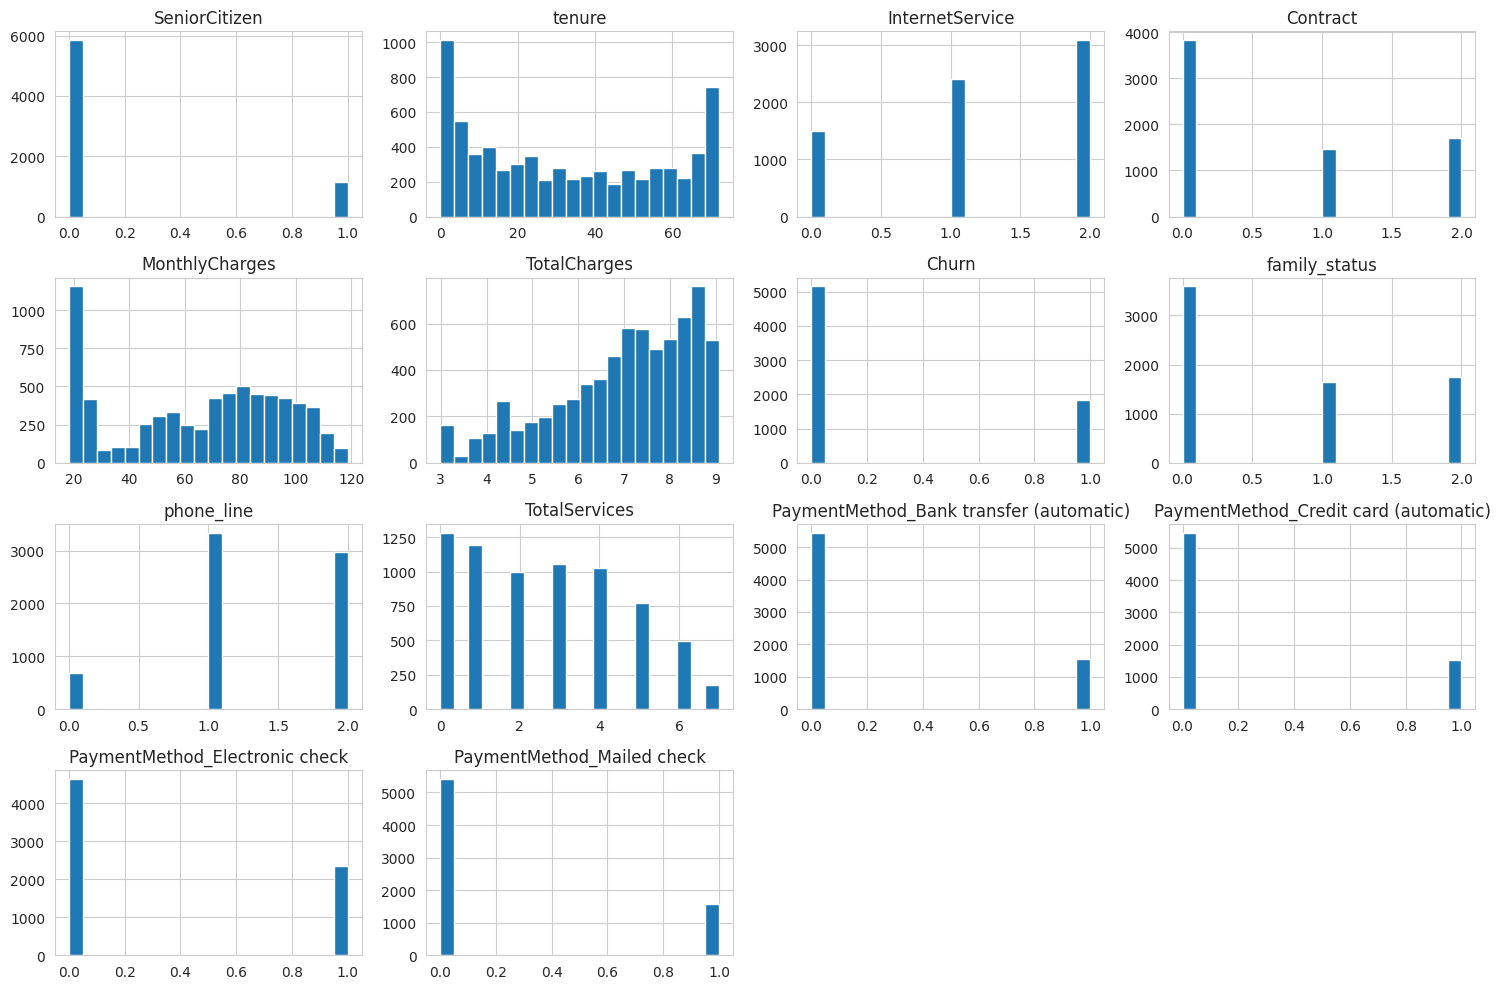

In [24]:
df.hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()

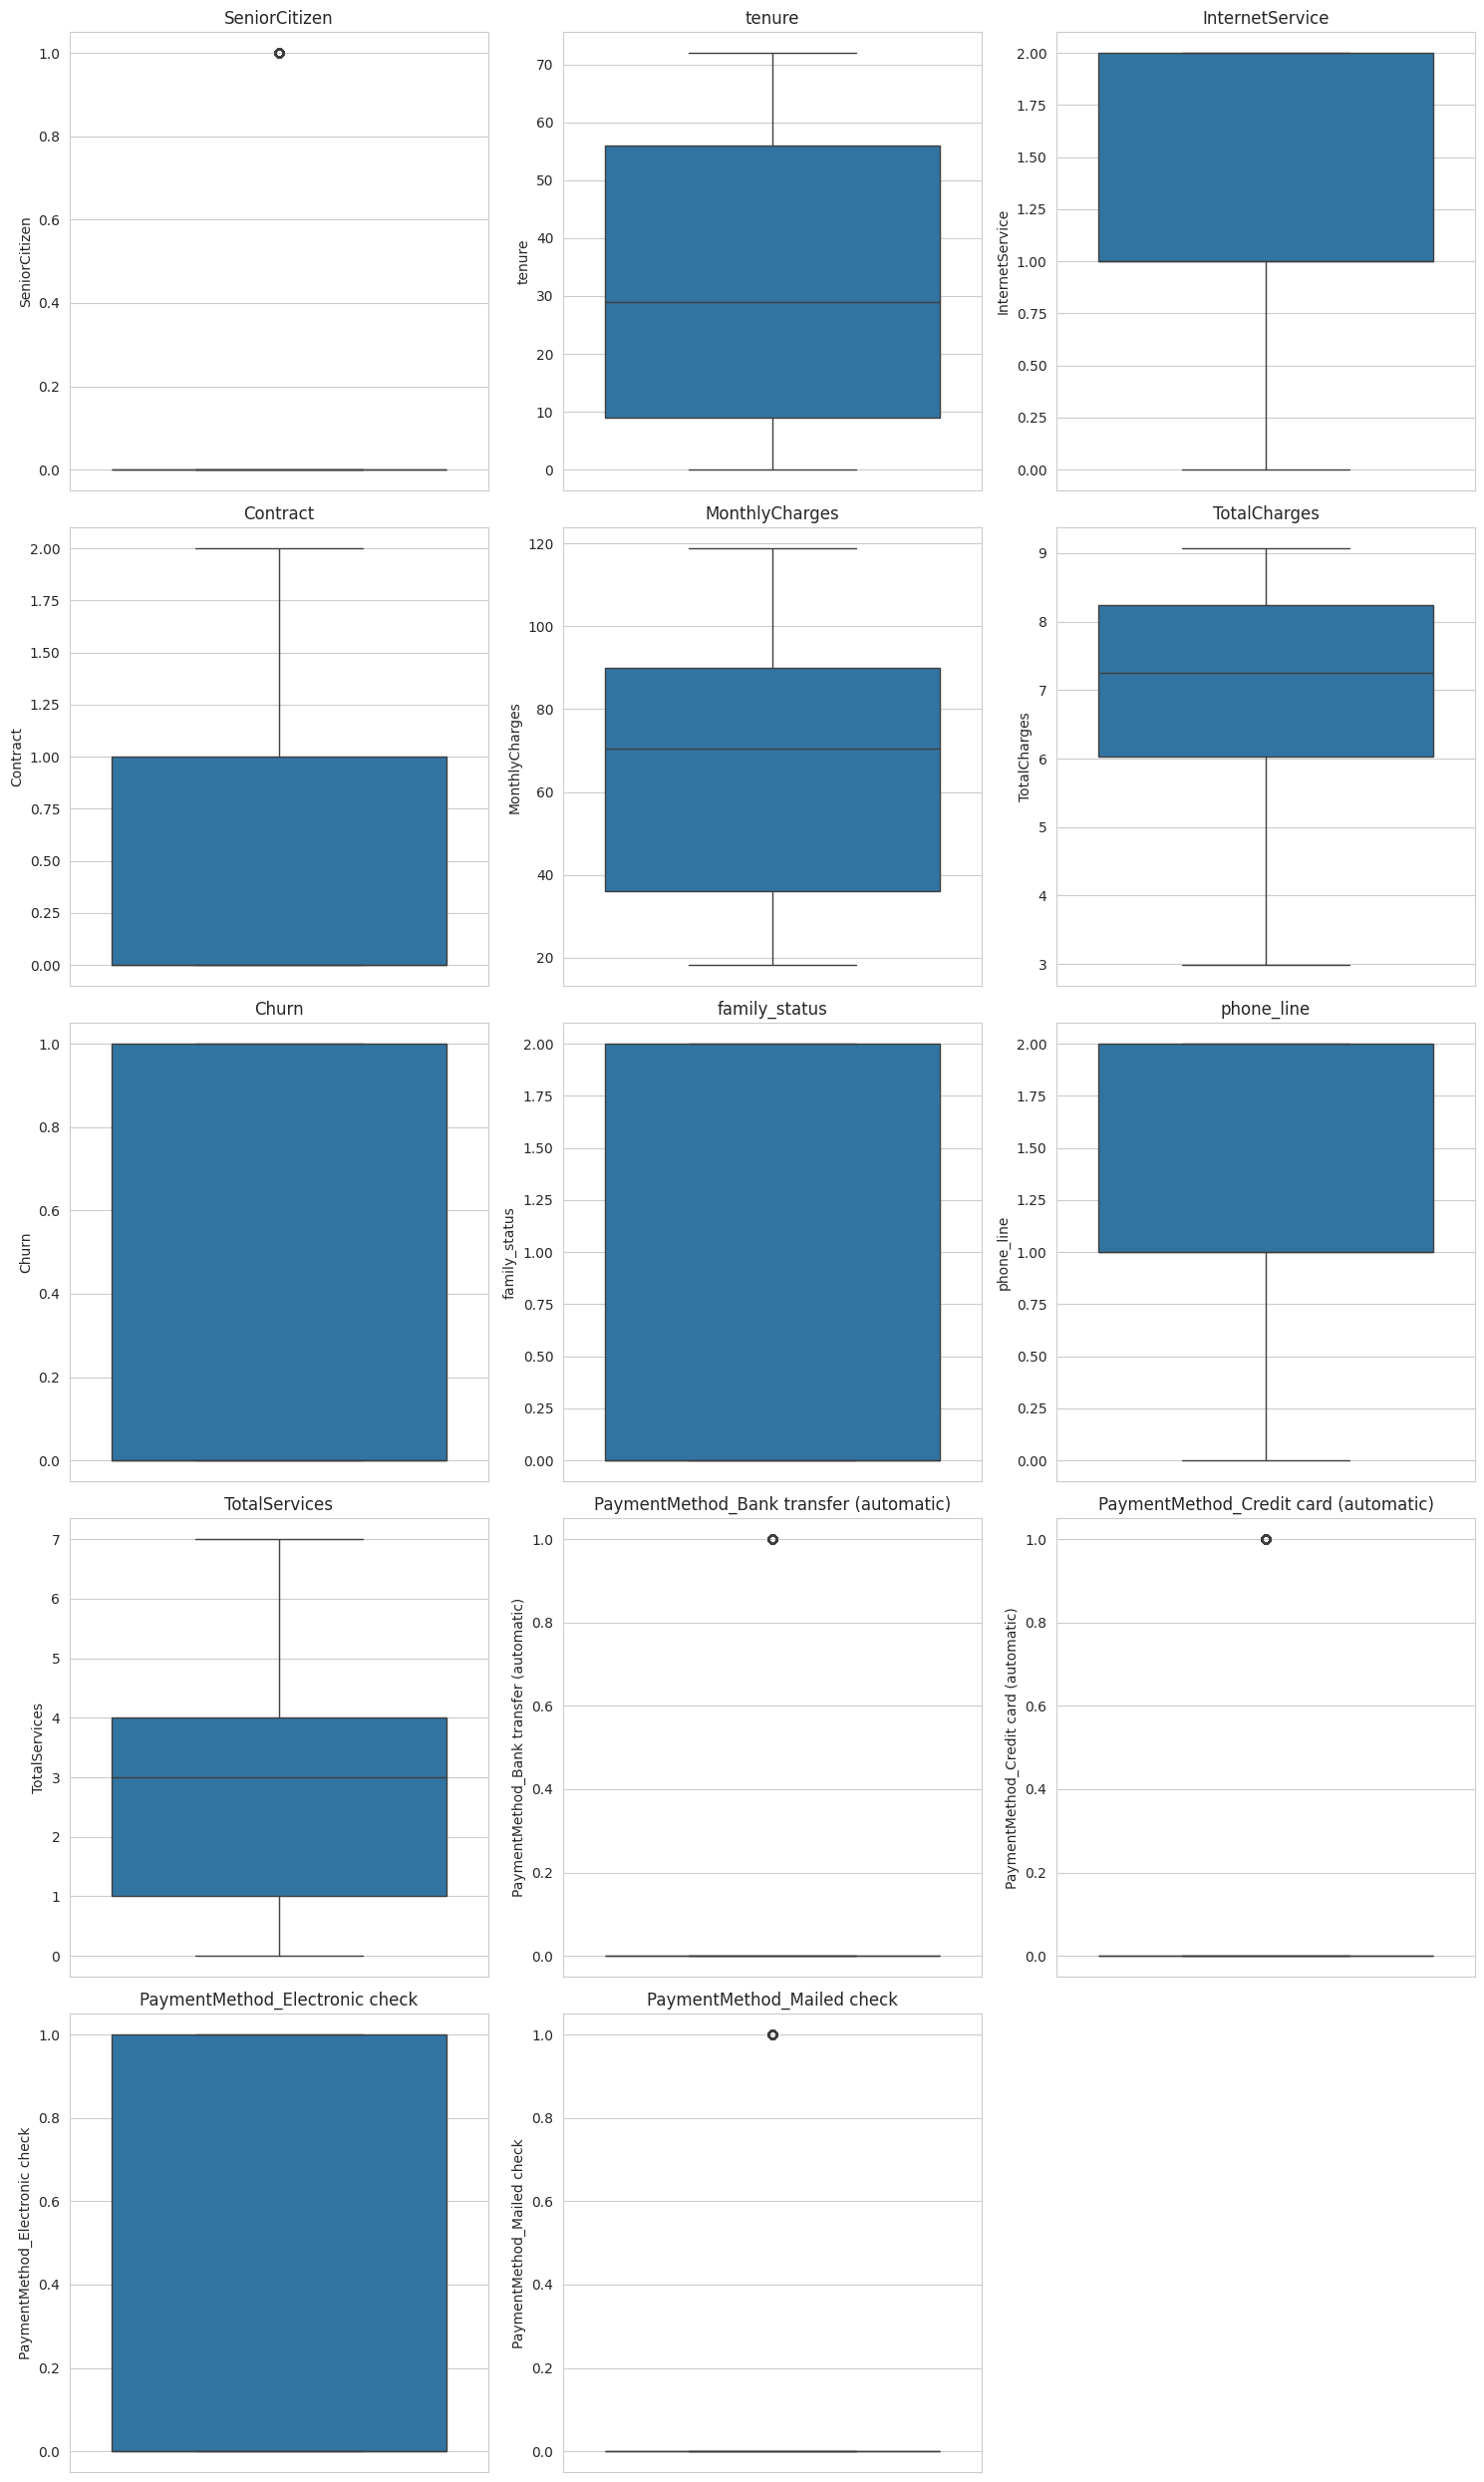

In [25]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

cols = 3
rows = (len(num_cols) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [26]:
#split data
x = df.drop(columns=["Churn"],axis=1)
y=df['Churn']

#test dataset
x_temp,x_test, y_temp, y_test =train_test_split(x, y,test_size=0.2, random_state=42)

#train and validate dataset
x_train,x_val, y_train, y_val =train_test_split(x_temp, y_temp,test_size=0.2, random_state=42)

print("Train:", x_train.shape)
print("Validation:", x_val.shape)
print("Test:", x_test.shape)



Train: (4475, 13)
Validation: (1119, 13)
Test: (1399, 13)


In [33]:
#modeling
#training
models={
    "LogisticRegression":LogisticRegression(),
    "DecisionTreeClassifier":DecisionTreeClassifier(),
    "RandomForestClassifier":RandomForestClassifier()
}

results=[]
resultstest=[]

for name, model in models.items():
  #TRANING
    model.fit(x_train, y_train)
    #validate
    y_pred = model.predict(x_val)

    #EVALUATING
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_val, y_pred),
        'Precision': precision_score(y_val, y_pred),
        'Recall': recall_score(y_val, y_pred),
        'F1': f1_score(y_val, y_pred)
    })

    y_pred_test = model.predict(x_test)

    #EVALUATING
    resultstest.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred_test),
        'Precision': precision_score(y_test, y_pred_test),
        'Recall': recall_score(y_test, y_pred_test),
        'F1': f1_score(y_test, y_pred_test)
    })

results_df = pd.DataFrame(results)
print(results_df)


resultstest_df = pd.DataFrame(resultstest)
print(resultstest_df)




                    Model  Accuracy  Precision    Recall        F1
0      LogisticRegression  0.801609   0.628319  0.507143  0.561265
1  DecisionTreeClassifier  0.739053   0.481250  0.550000  0.513333
2  RandomForestClassifier  0.778374   0.568376  0.475000  0.517510
                    Model  Accuracy  Precision    Recall        F1
0      LogisticRegression  0.784846   0.611801  0.528150  0.566906
1  DecisionTreeClassifier  0.724089   0.483117  0.498660  0.490765
2  RandomForestClassifier  0.770550   0.583333  0.487936  0.531387
